Make timelines and barplots of the evaluated pipeline

In [ ]:
timing_data = {"uploading stacks": 14.674841,
"adding ROIs": 20.123361,
"adding traces, snippets and averages": 10.543648 + 3.893219,
"adding quality metrics and cell type assignments": 2.202612 + 5.572227,
"generating STAs (all RGCs)": 43.830777,
"finding peak STA positions": 2.469733,
"spike estimation": 87.826443,
"extracting and preprocessing data for openretina": 7.169821 + 0.131654,
"training readout online": 24.339360,
"generating one MEI and saving it as AVI": 1.614335 + 0.013466,
}
total = sum(timing_data.values())
for key, value in timing_data.items():
    print(f"{key} {value:.1f} s")

print(f"Total time: {total:.1f} s")
print(f"Total time: {total // 60} min and {total % 60:.1f} s")



uploading stacks 14.7 s
adding ROIs 20.1 s
adding traces, snippets and averages 14.4 s
adding quality metrics and cell type assignments 7.8 s
generating STAs (all RGCs) 43.8 s
finding peak STA positions 2.5 s
spike estimation 87.8 s
extracting and preprocessing data for openretina 7.3 s
training readout online 24.3 s
generating one MEI and saving it as AVI 1.6 s
Total time: 224.4 s
Total time: 3.0 min and 44.4 s


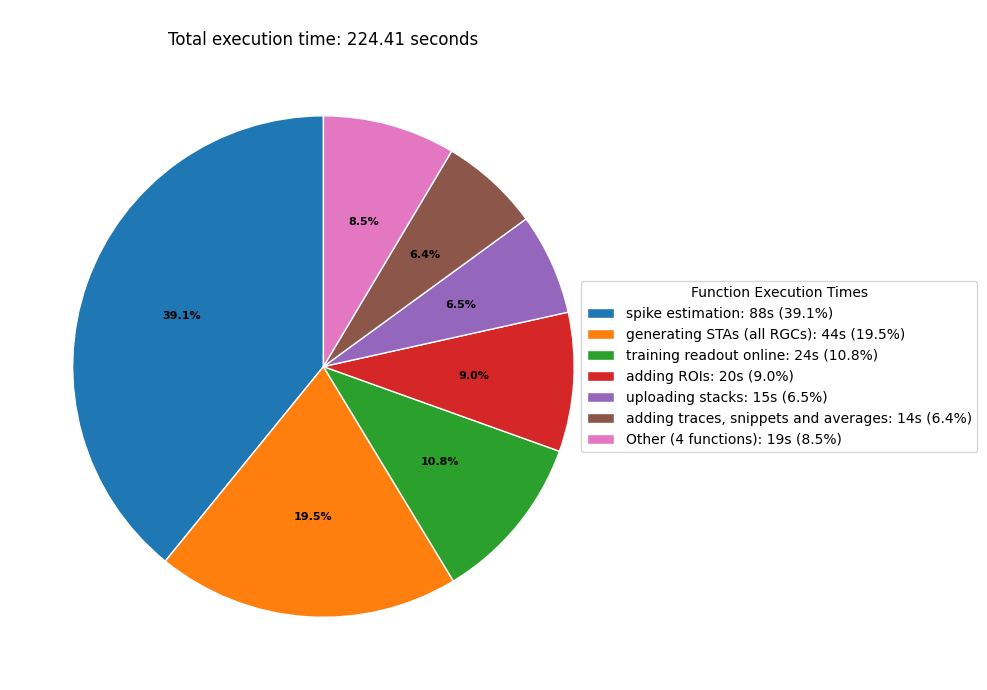

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict
import numpy as np
from typing import Dict, Optional, Tuple, List


def plot_timing_pie(timing_data: Dict[str, float], 
                    title: str = "Execution Time Distribution",
                    figsize: tuple = (10, 7),
                    min_percentage: float = 1.0,
                    colors: Optional[List[str]] = None,
                    explode_largest: bool = True):
    """
    Create a pie chart showing the distribution of execution times.
    
    Parameters:
    -----------
    timing_data : Dict[str, float]
        Dictionary with function names as keys and execution times as values
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height) in inches
    min_percentage : float
        Minimum percentage for a segment to be shown separately; smaller segments
        will be grouped into "Other"
    colors : Optional[List[str]]
        Optional list of colors to use; if None, default colormap is used
    explode_largest : bool
        Whether to slightly explode the largest segment
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Sort data by execution time (descending)
    sorted_items = sorted(timing_data.items(), key=lambda x: x[1], reverse=True)
    
    # Calculate total time
    total_time = sum(timing_data.values())
    
    # Calculate percentages and prepare labels
    names = []
    times = []
    percentages = []
    
    # Group small segments
    other_time = 0
    other_count = 0
    
    for name, time in sorted_items:
        percentage = time / total_time * 100
        if percentage >= min_percentage:
            names.append(name)
            times.append(time)
            percentages.append(percentage)
        else:
            other_time += time
            other_count += 1
    
    # Add "Other" category if needed
    if other_time > 0:
        names.append(f"Other ({other_count} functions)")
        times.append(other_time)
        percentages.append(other_time / total_time * 100)
    
    # Create explode array (to highlight largest segment)
    explode = None
    if explode_largest and len(times) > 1:
        explode = [0.1 if i == 0 else 0 for i in range(len(times))]
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create custom labels
    labels = [f"{name}" for name in names]
    
    # Create the pie chart
    wedges, texts, autotexts = ax.pie(
        times, 
        explode=explode,
        labels=None,  # We'll add custom labels
        autopct='%1.1f%%',
        startangle=90,
        shadow=False,
        colors=colors,
        wedgeprops={'edgecolor': 'w', 'linewidth': 1}
    )
    
    # Customize autopct text
    for i, autotext in enumerate(autotexts):
        autotext.set_fontsize(8)
        autotext.set_fontweight('bold')
    
    # Add a legend
    formatted_labels = []
    for i, (name, time, pct) in enumerate(zip(names, times, percentages)):
        time_str = f"{time:.1f}s" if time < 10 else f"{time:.0f}s"
        formatted_labels.append(f"{name}: {time_str} ({pct:.1f}%)")
    
    ax.legend(wedges, formatted_labels, 
              title="Function Execution Times",
              loc="center left", 
              bbox_to_anchor=(0.9, 0, 0.5, 1))
    
    # Add title with total time
    ax.set_title(f"{title}\nTotal execution time: {total_time:.2f} seconds")
    
    plt.tight_layout()
    return fig, ax


fig, ax = plot_timing_pie(timing_data, min_percentage=4.0,title='', explode_largest=False,)
plt.show()